In [1]:
import pandas as pd

import matplotlib.pyplot as plt
df = pd.read_csv('train.csv')
calender_events =  pd.read_csv('calendar_events.csv')
df = df.merge( calender_events, on='date', how = 'left')
df['date'] = pd.to_datetime(df['date'])
df

,store_id,store_name,date,revenue,event
0,0,All Stores,2011-01-29,204126.52,NaN
1,0,All Stores,2011-01-30,197426.42,NaN
2,0,All Stores,2011-01-31,144267.27,NaN
3,0,All Stores,2011-02-01,151903.00,NaN
4,0,All Stores,2011-02-02,117399.88,NaN
...,...,...,...,...,...
18761,10,Wisconsin – Badger Crossing,2015-09-26,25689.55,NaN
18762,10,Wisconsin – Badger Crossing,2015-09-27,26557.53,NaN
18763,10,Wisconsin – Badger Crossing,2015-09-28,19067.53,NaN
18764,10,Wisconsin – Badger Crossing,2015-09-29,16467.95,NaN


Text(0.5, 1.0, 'Events Averaged Revenue')

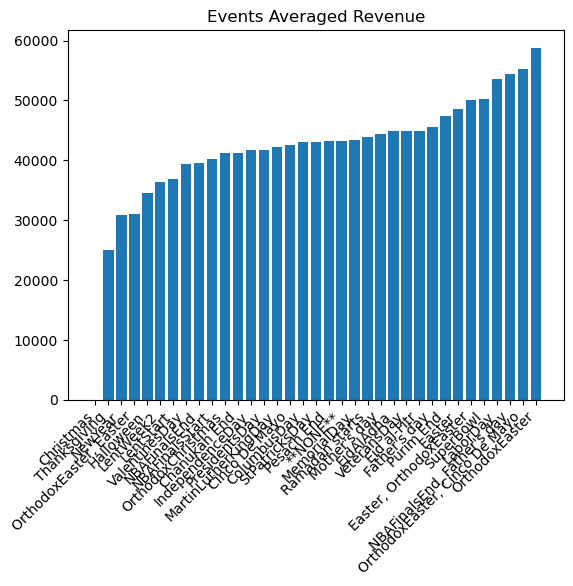

In [2]:
calendar = df.fillna('**NONE**').groupby('event')['revenue'].mean().sort_values()
plt.bar(calendar.index, calendar)
plt.xticks(rotation=45, ha='right')
plt.title('Events Averaged Revenue')

# Feature Engineering 

In [3]:
import pandas as pd
import numpy as np

def engineer_multioutput_features(df, horizon_days=92, is_training=True):
    """
    Generates features and a multi-column target matrix for a 
    MultiOutputRegressor LightGBM model.
    
    Parameters:
    - is_training: If True, drops the last 92 days so the model has complete targets to learn from.
                   If False, keeps the last days so you can forecast the true future.
    """
    # 0. Ensure chronological order (Critical for shift/rolling)
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)
    
    # ==========================================
    # 1. Deterministic Calendar Features (State at Day T)
    # ==========================================
    df['day_of_week'] = df['date'].dt.dayofweek.astype('category')
    df['day_of_month'] = df['date'].dt.day.astype('category')
    df['month'] = df['date'].dt.month.astype('category')
    
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Cyclical Encodings for day of year
    day_of_year = df['date'].dt.dayofyear
    df['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Fill NaN events with a placeholder
    df['event'] = df['event'].fillna('None')
    df['is_event'] = (df['event'] != 'None').astype(int)
    df['is_christmas'] = (df['event'] == 'Christmas').astype(int)
    
    # ==========================================
    # 2. Target-Safe Autoregressive Features (Recent Lags)
    # ==========================================
    lags = [1, 2, 7, 14, 28, 364]
    for lag in lags:
        df[f'revenue_lag_{lag}'] = df.groupby('store_id')['revenue'].shift(lag)

    # ==========================================
    # 3. Momentum & Volatility (Recent Rolling Windows)
    # ==========================================
    windows = [7, 28]
    for window in windows:
        df[f'rolling_mean_{window}d'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        df[f'rolling_std_{window}d'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.rolling(window=window, min_periods=1).std()
        )
        df[f'rolling_max_{window}d'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.rolling(window=window, min_periods=1).max()
        )

    # ==========================================
    # 4. Target Matrix Generation (Y_1 to Y_92)
    # ==========================================
    target_cols = []
    for lead in range(1, horizon_days + 1):
        col_name = f'target_day_{lead}'
        df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
        target_cols.append(col_name)

    # ==========================================
    # 5. Model Preparations & Cleaning
    # ==========================================
    df['store_id'] = df['store_id'].astype('category')
    
    # ALWAYS drop the beginning of the dataset where historical lags are missing
    df_cleaned = df.dropna(subset=[f'revenue_lag_{max(lags)}']).reset_index(drop=True)
    
    # CONDITIONALLY drop the end of the dataset
    if is_training:
        # Drop rows where the future hasn't happened yet
        df_cleaned = df_cleaned.dropna(subset=[f'target_day_{horizon_days}']).reset_index(drop=True)
    
    return df_cleaned, target_cols

In [4]:
def plot_results(pred, real, pred_target_name ='revenue'):
    plt.plot(pred['date'], pred[pred_target_name], label = 'prediction')
    plt.plot(real['date'], real['revenue'], label = 'real')
    plt.legend()
    plt.show()
    pass
    
    

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

def train_multi_output_tweedie(df, target_cols, horizon_days=92):
    """
    Trains a MultiOutputRegressor wrapped LightGBM model per store using Tweedie loss.
    Includes a plot of the first 92-day forecast slice vs actuals for visual validation.
    """
    drop_cols = ['date', 'revenue', 'store_name', 'event'] + target_cols
    feature_cols = [col for col in df.columns if col not in drop_cols]
    
    store_results = {}
    
    for store in df['store_id'].unique():
        print(f"--- Training Multi-Output Tweedie Model for Store: {store} ---")
        store_df = df[df['store_id'] == store].copy()
        
        # Chronological Split
        max_date = store_df['date'].max()
        split_date = max_date - pd.Timedelta(days=horizon_days)
        
        train_mask = store_df['date'] <= split_date
        val_mask = store_df['date'] > split_date
        
        X_train = store_df.loc[train_mask, feature_cols]
        y_train = store_df.loc[train_mask, target_cols]
        
        X_val = store_df.loc[val_mask, feature_cols]
        y_val = store_df.loc[val_mask, target_cols]
        
        # Skip if validation set is empty
        if len(X_val) == 0:
            print(f"Skipping Store {store}: Not enough data for validation split.")
            continue
        
        # Enforce categorical dtypes
        for col in ['day_of_week']:
            if col in X_train.columns:
                X_train[col] = X_train[col].astype('category')
                X_val[col] = X_val[col].astype('category')

        base_model = lgb.LGBMRegressor(
            objective='tweedie',
            tweedie_variance_power=1.5,
            boosting_type='gbdt',
            learning_rate=0.05,
            num_leaves=31,
            n_estimators=150,
            feature_fraction=0.8,
            random_state=42,
            verbose=-1
        )
        
        multi_output_model = MultiOutputRegressor(base_model)
        multi_output_model.fit(X_train, y_train)
        preds = multi_output_model.predict(X_val)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        print(f"Store {store} Multi-Output Matrix RMSE: {rmse:.2f}\n")
        
        # ==========================================
        # VISUALIZATION BLOCK
        # ==========================================
        # Extract the very first row (Day T) of the validation set
        # This shows a continuous 92-day trajectory
        single_actual = y_val.iloc[0, :].values
        single_pred = preds[0, :]
        
        plt.figure(figsize=(12, 5))
        days_axis = np.arange(1, horizon_days + 1)
        
        plt.plot(days_axis, single_actual, label='Actual Revenue', marker='.', color='black', alpha=0.6)
        plt.plot(days_axis, single_pred, label='Predicted Revenue (Tweedie)', marker='', color='blue', linewidth=2)
        
        plt.title(f"Store {store}: 92-Day Forecast vs Actuals (From first day of Validation)")
        plt.xlabel("Days into the Future (1 to 92)")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        # ==========================================
        
        # Save results
        store_results[store] = {}
        store_results[store]['preds'] = preds
        store_results[store]['real'] = y_val
        store_results[store]['model'] = multi_output_model
        
    return store_results

In [6]:
def plot_results(pred, real, pred_target_name ='revenue'):
    plt.plot(pred['date'], pred[pred_target_name], label = 'prediction')
    plt.plot(real['date'], real['revenue'], label = 'real')
    plt.legend()
    plt.show()
    pass
    
    

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

--- Training Multi-Output Tweedie Model for Store: 0 ---
Store 0 Multi-Output Matrix RMSE: 23948.46



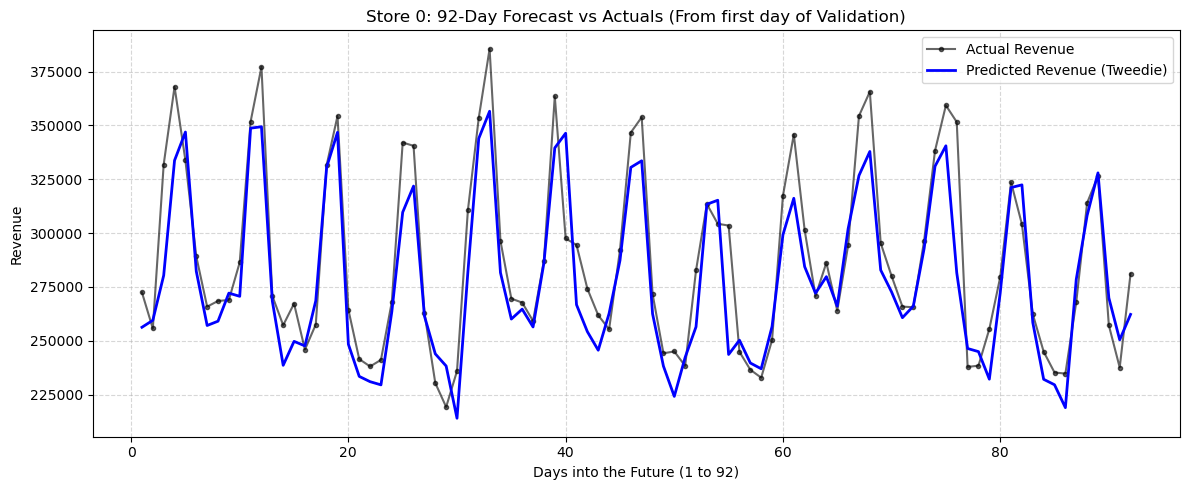

--- Training Multi-Output Tweedie Model for Store: 1 ---
Store 1 Multi-Output Matrix RMSE: 3203.25



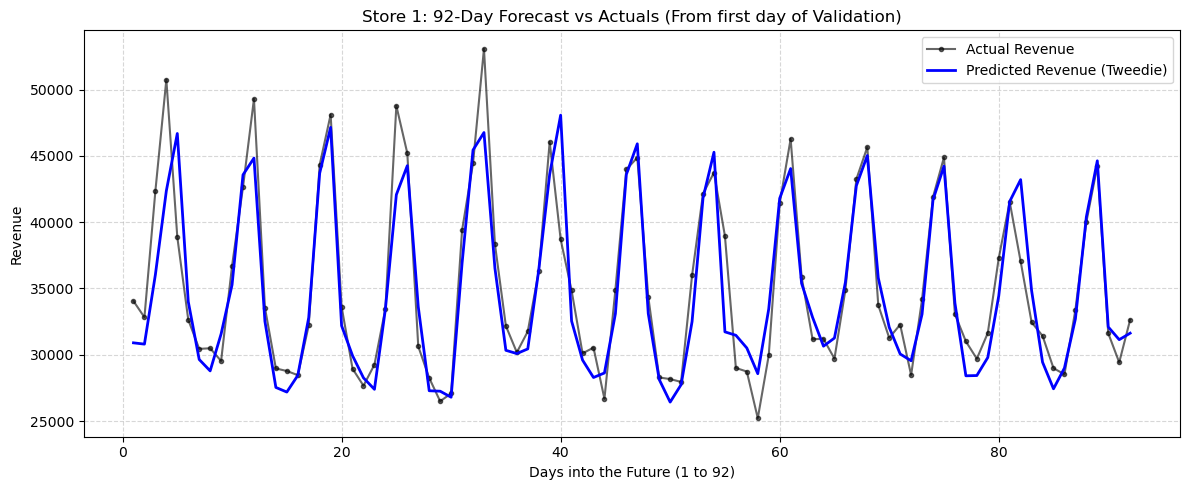

--- Training Multi-Output Tweedie Model for Store: 2 ---
Store 2 Multi-Output Matrix RMSE: 7125.66



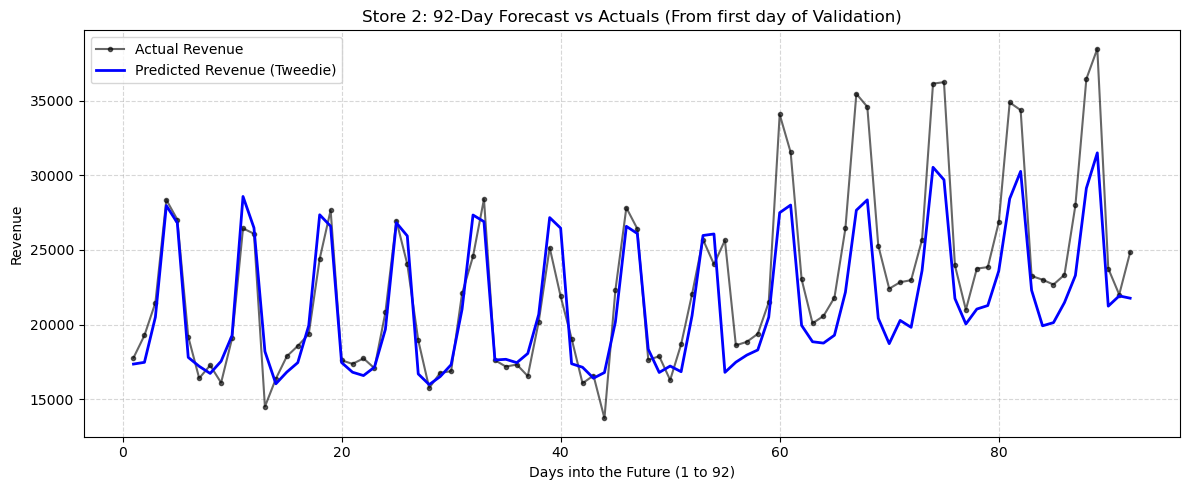

--- Training Multi-Output Tweedie Model for Store: 3 ---
Store 3 Multi-Output Matrix RMSE: 3753.23



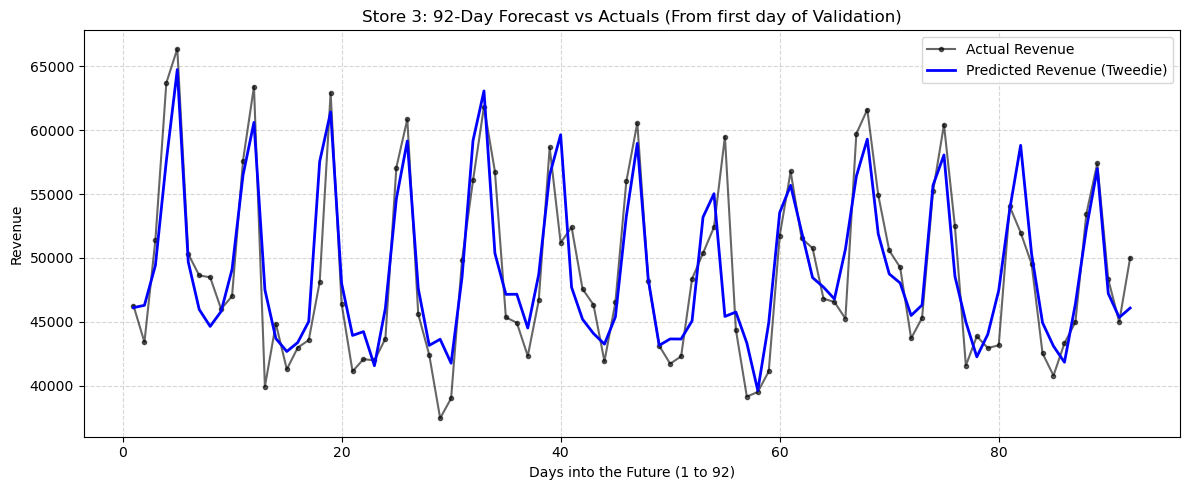

--- Training Multi-Output Tweedie Model for Store: 4 ---
Store 4 Multi-Output Matrix RMSE: 1571.14



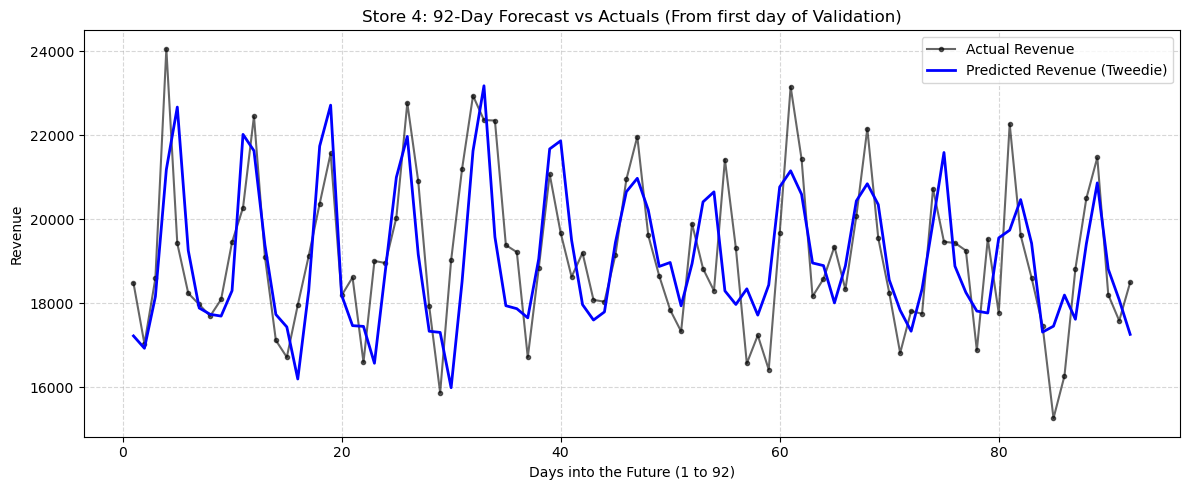

--- Training Multi-Output Tweedie Model for Store: 5 ---
Store 5 Multi-Output Matrix RMSE: 2658.08



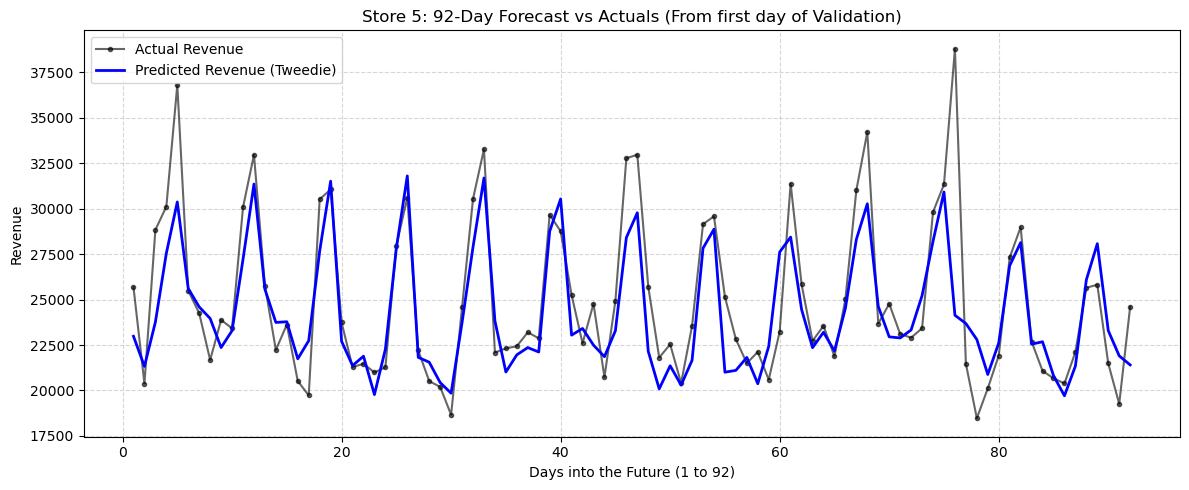

--- Training Multi-Output Tweedie Model for Store: 6 ---
Store 6 Multi-Output Matrix RMSE: 3195.94



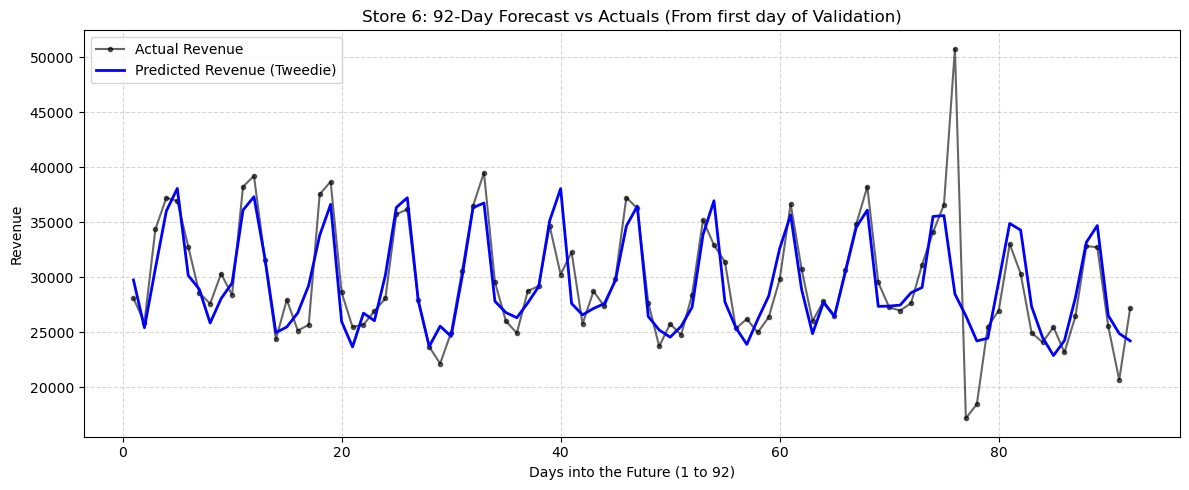

--- Training Multi-Output Tweedie Model for Store: 7 ---
Store 7 Multi-Output Matrix RMSE: 3797.25



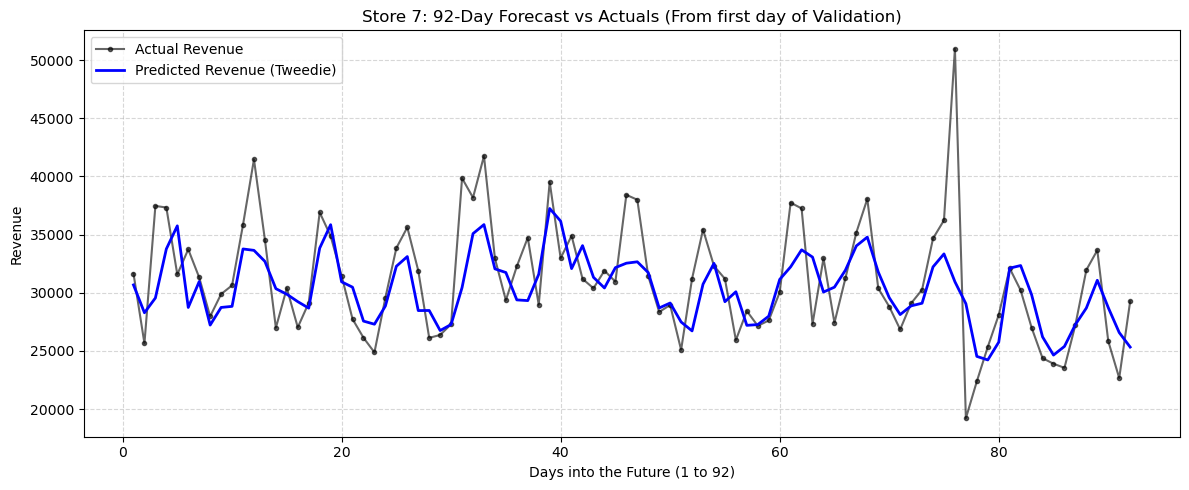

--- Training Multi-Output Tweedie Model for Store: 8 ---
Store 8 Multi-Output Matrix RMSE: 2780.31



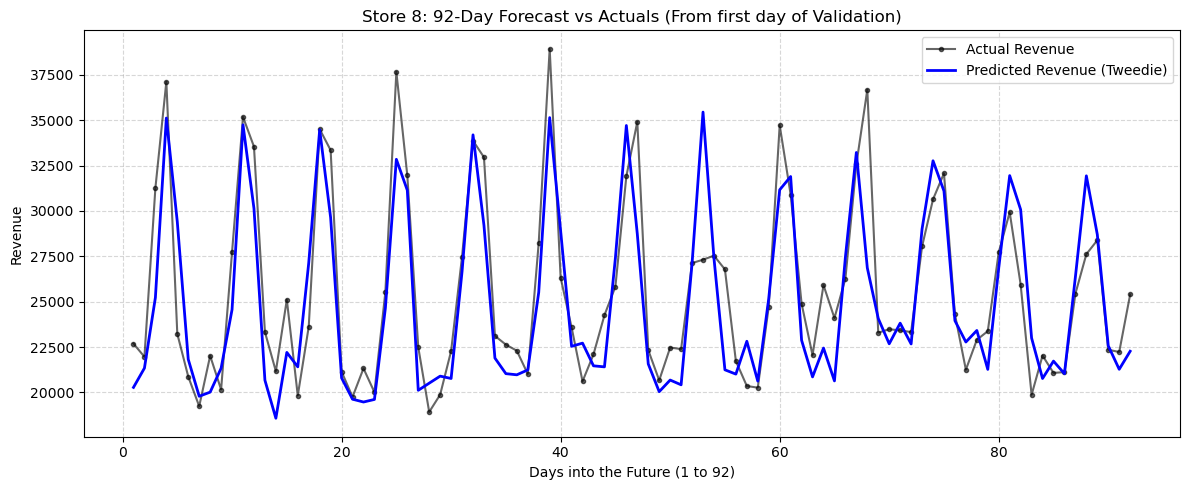

--- Training Multi-Output Tweedie Model for Store: 9 ---
Store 9 Multi-Output Matrix RMSE: 2666.79



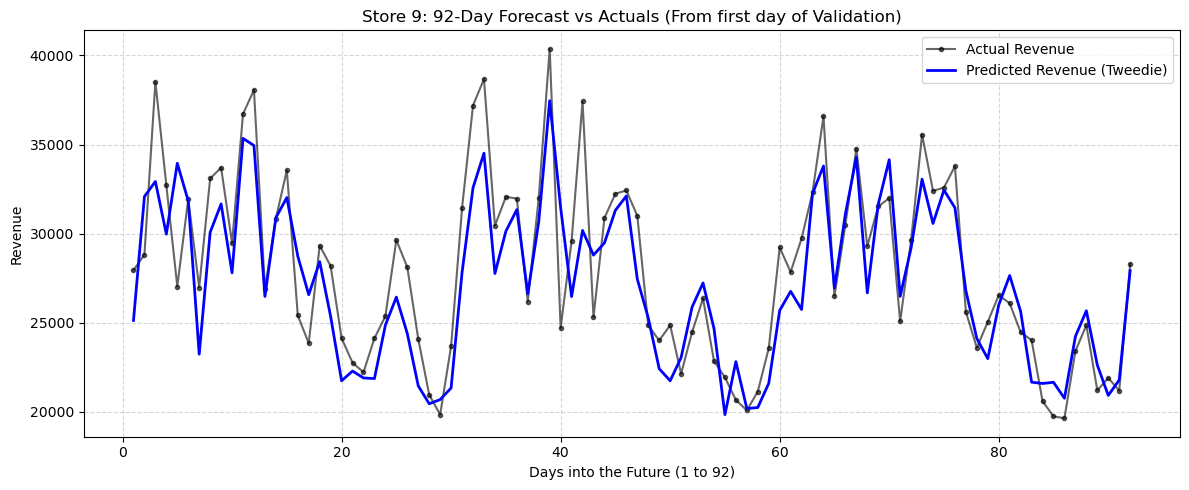

--- Training Multi-Output Tweedie Model for Store: 10 ---
Store 10 Multi-Output Matrix RMSE: 2408.96



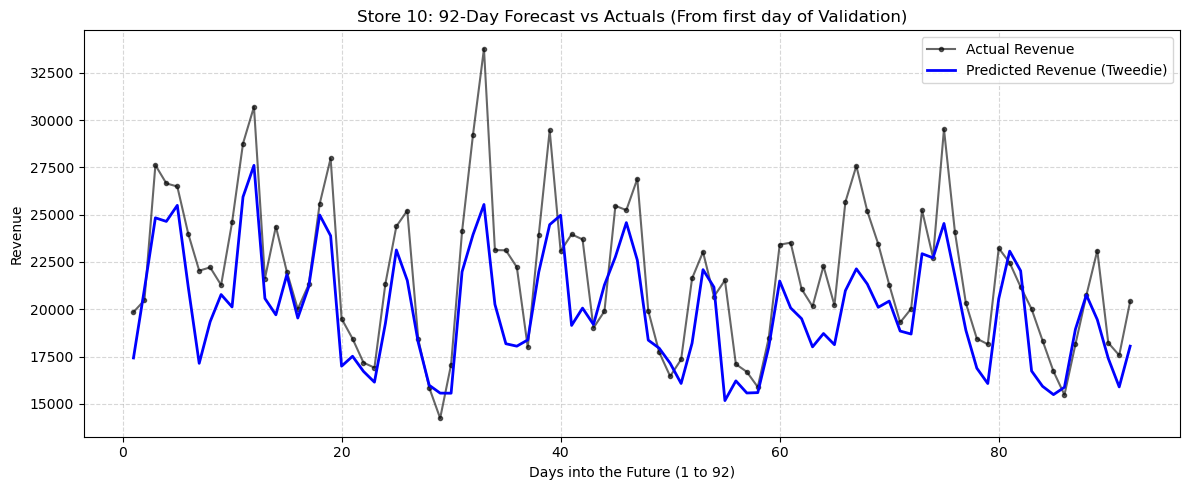

In [7]:
df_mof, targets = engineer_multioutput_features(df)
results = train_multi_output_tweedie(df_mof, targets)



In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor

def generate_production_forecast(df, target_cols, horizon_days=92):
    """
    Trains on ALL available historical data and predicts the true future 92 days.
    Returns a clean, decipherable DataFrame of future dates and revenues per store.
    """
    # Ensure chronological order
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)
    
    # Identify features
    drop_cols = ['date', 'revenue', 'store_name', 'event'] + target_cols
    feature_cols = [col for col in df.columns if col not in drop_cols]
    
    all_store_forecasts = []
    
    unique_stores = df['store_id'].unique()
    print(f"Generating true future forecasts for {len(unique_stores)} stores...\n")
    
    for store in unique_stores:
        print(f"Training & Forecasting Store: {store}")
        store_df = df[df['store_id'] == store].copy()
        
        # ==========================================
        # 1. Split Training Data vs "Today"
        # ==========================================
        # Training Set: Rows where we ACTUALLY have the future 92 days to learn from.
        # We drop rows where the furthest target (target_day_92) is NaN.
        train_df = store_df.dropna(subset=[target_cols[-1]]).copy()
        
        # Inference Set: The absolute last chronological day in the dataset.
        # This row has NaNs for the future targets, which is exactly what we want to predict!
        inference_row = store_df.tail(1).copy()
        last_known_date = inference_row['date'].iloc[0]
        
        # ==========================================
        # 2. Prepare X and Y Matrices
        # ==========================================
        X_train = train_df[feature_cols]
        Y_train = train_df[target_cols]
        
        X_infer = inference_row[feature_cols]
        
        # Enforce categorical datatypes
        for col in ['day_of_week']:
            if col in feature_cols:
                X_train[col] = X_train[col].astype('category')
                X_infer[col] = X_infer[col].astype('category')
                
        # ==========================================
        # 3. Train on 100% of Known Data
        # ==========================================
        # We cannot use early stopping because there is no validation set!
        # We lock in the n_estimators to a stable number (e.g., 150 or whatever 
        # your best_iteration was during your validation phase).
        base_model = lgb.LGBMRegressor(
            objective='tweedie',
            tweedie_variance_power=1.5,
            boosting_type='gbdt',
            learning_rate=0.05,
            num_leaves=31,
            n_estimators=150, 
            feature_fraction=0.8,
            random_state=42,
            verbose=-1
        )
        
        multi_output_model = MultiOutputRegressor(base_model)
        multi_output_model.fit(X_train, Y_train)
        
        # ==========================================
        # 4. Predict the True Future
        # ==========================================
        # Predict returns a 2D matrix. We slice [0] to get the 1D array of 92 values.
        future_preds = multi_output_model.predict(X_infer)[0]
        
        # Prevent Tweedie from occasionally outputting a negative fraction
        future_preds = np.clip(future_preds, a_min=0, a_max=None)
        
        # ==========================================
        # 5. Format the Output
        # ==========================================
        # Generate the exact calendar dates for the next 92 days
        future_dates = pd.date_range(start=last_known_date + pd.Timedelta(days=1), periods=horizon_days)
        
        store_forecast = pd.DataFrame({
            'store_id': store,
            'date': future_dates,
            'predicted_revenue': future_preds
        })
        
        all_store_forecasts.append(store_forecast)
        
    # Combine everything into one clean master table
    final_forecast_df = pd.concat(all_store_forecasts, ignore_index=True)
    
    print("\n✅ All forecasts generated successfully.")
    return final_forecast_df

# ==========================================
# EXECUTION
# ==========================================
# 1. Ensure your feature generation didn't drop the last row!
# raw_features_df, target_columns = engineer_multioutput_features(raw_data)

# 2. Run the production function
# future_predictions = generate_production_forecast(raw_features_df, target_columns)

# 3. View the results
# print(future_predictions.head(10))

In [10]:
df_mof, targets = engineer_multioutput_features(df, is_training=False)
res = generate_production_forecast(df_mof, targets, horizon_days=92)

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

Generating true future forecasts for 11 stores...

Training & Forecasting Store: 0
Training & Forecasting Store: 1


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')


Training & Forecasting Store: 2


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')


...

Training & Forecasting Store: 9


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')


Training & Forecasting Store: 10


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')



✅ All forecasts generated successfully.


In [40]:
res['id'] = res['store_id'].astype(str)+ '_' + res['date'].astype(str).str.replace('-', '')
res = res.rename(columns={'predicted_revenue': 'prediction'})


is_christmas = (res['date'].dt.month == 12) & (res['date'].dt.day == 25)

# 3. Use .loc to assign exactly 0 to the 'predicted_revenue' column for those days
res.loc[is_christmas, 'prediction'] = 0


res[['id', 'prediction']].iloc[:,:2].set_index('id').to_csv('best_multiOutReg.csv')